## Building an inverted index

**Author:** Diego Besada

Created using [Pierre Nugues' template](https://github.com/pnugues/edan20/blob/master/labs_2026/1-indexer.ipynb)

Conceptually, an index consists of rows with one word per row and the list of files and positions, where this word occurs. Such a row is called a _posting list_.  The position of a word will be represented by the number of characters from the start of the file.

<pre>
word1: file_name pos1 pos2 pos3... file_name pos1 pos2 ...
word2: file_name pos1 pos2 pos3... file_name pos1 pos2 ...
...
</pre>

In [1]:
import math, requests, os, json, seaborn
import matplotlib.pyplot as plt, regex as re, pandas as pd
from zipfile import ZipFile
from collections import defaultdict

In [2]:
SELMA_URL = 'https://github.com/pnugues/ilppp/raw/master/programs/corpus/Selma.zip'
FILE_NAMES = ['bannlyst.txt', 'gosta.txt', 'herrgard.txt', 'jerusalem.txt', 
              'kejsaren.txt', 'marbacka.txt', 'nils.txt', 'osynliga.txt', 'troll.txt']
SELMA_FILES = [os.path.join('Selma', fname) for fname in FILE_NAMES]

if not all([os.path.exists(fname) for fname in SELMA_FILES]):
    req = requests.get(SELMA_URL, stream=True)
    with open('Selma.zip', 'wb') as file:
        written = 0
        for chunk in req.iter_content(chunk_size=65536):
            file.write(chunk)
            written += len(chunk)
    req.close()

    selma_zipfile = ZipFile('Selma.zip')
    selma_files_to_extract = [zi for zi in selma_zipfile.filelist if not zi.filename.startswith('__') and zi.filename.endswith('.txt')]
    for zi in selma_files_to_extract:
        selma_zipfile.extract(zi)
    os.remove('Selma.zip')

To make programming easier, the code is split into five steps:
1. Index one file
2. Read the content of a folder
3. Create a master index for all the files
4. Use tfidf to represent the documents (novels)
5. Compare the documents of a collection

#### 1. Index one file

Using `regex`, we will create the function `tokenize(text)`. It returns their positions.

In [3]:
def tokenize(text: str) -> re.Scanner:
    '''Tokenizes the input text into a list of words.'''
    return re.finditer(r'\p{L}+', text.lower())

In [4]:
tokens = tokenize('En gång hade de på Mårbacka en barnpiga, som hette Back-Kajsa.')
list(tokens)

[<regex.Match object; span=(0, 2), match='en'>,
 <regex.Match object; span=(3, 7), match='gång'>,
 <regex.Match object; span=(8, 12), match='hade'>,
 <regex.Match object; span=(13, 15), match='de'>,
 <regex.Match object; span=(16, 18), match='på'>,
 <regex.Match object; span=(19, 27), match='mårbacka'>,
 <regex.Match object; span=(28, 30), match='en'>,
 <regex.Match object; span=(31, 39), match='barnpiga'>,
 <regex.Match object; span=(41, 44), match='som'>,
 <regex.Match object; span=(45, 50), match='hette'>,
 <regex.Match object; span=(51, 55), match='back'>,
 <regex.Match object; span=(56, 61), match='kajsa'>]

Then, we will create a `text_to_idx(words)` function to extract the indices from the list of tokens (words). The function will return a dictionary, where the keys will be the tokens (words), and the values a list of positions.

In [5]:
def text_to_idx(words: re.Scanner) -> defaultdict[str, list[int]]:
    idx: defaultdict[str, list] = defaultdict(list)
    for w in words:
        idx[w.group()].append(w.start())
    return idx

In [6]:
# tokens = tokenize('En gång hade de på Mårbacka en barnpiga, som hette Back-Kajsa.'.lower().strip())
# text_to_idx(tokens)

Now, we will process one file, _Mårbacka_, `marbacka.txt`, tokenize it, and index it. The index will be stored in the index `idx`

In [7]:
with open('Selma/marbacka.txt', 'r', encoding='utf-8') as f:
    marbacka_text: str = f.read().lower().strip()

idx: defaultdict[str, list[int]] = text_to_idx(tokenize(marbacka_text))

We will save it into `idx/marbacka.json` using the `json` format.

In [8]:
index_file = 'idx/marbacka.json'
with open(index_file, 'w', encoding='utf-8') as fp:
    json.dump(idx, fp, ensure_ascii=False, indent=4)

#### 2. Read the content of a folder

In [9]:
def get_files(dir: str, suffix: str) -> list[str]:
    '''Returns all the files in a folder ending with suffix.'''
    files = []
    for file in os.listdir(dir):
        if file.endswith(suffix):
            files.append(file)
    return files

corpus_files = get_files('Selma', '.txt')

#### 3. Create a master index
Now, a master index is needed. It will be a dictionary like the one below. The keys will be the words, and the values will be a dictionary with the file names as keys and the list of positions as values.

```json
{'samlar':
            {'troll.txt': [641880, 654233],
            'nils.txt': [51805, 118943],
            'osynliga.txt': [399121],
            'gosta.txt': [313784, 409998, 538165]},
 'ände':
            {'troll.txt': [39562, 650112],
            'kejsaren.txt': [50171],
            'marbacka.txt': [370324],
            'nils.txt': [1794],
            'osynliga.txt': [272144]}
}
```

In [10]:
def corpus_to_master_idx(corpus_files: list[str]) -> defaultdict[str, dict[str, list[int]]]:
    '''Creates a master index for all the files in the corpus.'''
    master_idx: defaultdict[str, dict[str, list[int]]] = defaultdict(dict)
    for file in corpus_files:
        with open(f'Selma/{file}', 'r', encoding='utf-8') as f:
            text: str = f.read().lower().strip()
            words: re.Scanner = tokenize(text)
            idx: defaultdict[str, list[int]] = text_to_idx(words)
            for word in idx:
                master_idx[word][file] = idx[word]
    return master_idx

master_idx = corpus_to_master_idx(corpus_files)

In [11]:
with open('idx/master.json', 'w', encoding='utf-8') as fp:
    json.dump(master_idx, fp, ensure_ascii=False, indent=4)

In [12]:
with open('idx/master.json', 'r', encoding='utf-8') as f:
    master_idx = json.load(f)

Now we will create a `concordance(word, master_index, window)` function to extract the concordances of a `word` within a window of `window` characters.

In [ ]:
def concordance(word: str, master_index: defaultdict[str, dict[str, list[int]]], window: int) -> dict[str, list[str]]:
    '''Extracts the concordances of a word within a window of characters.'''
    concordances: defaultdict[str, list[str]] = defaultdict(list)
    if word in master_index:
        for file, positions in master_index[word].items():
            with open(f'Selma/{file}', 'r', encoding='utf-8') as f:
                text: str = f.read().lower().strip()
                for pos in positions:
                    start = max(0, pos - window)
                    # Slicing from word end (pos + len(word) + window) rather than word start (pos + window)
                    end = min(len(text), pos + len(word) + window)
                    concordance_text = text[start:end]
                    concordances[file].append(concordance_text)
    return concordances

In [14]:
concordance('samlar', master_idx, 25)

defaultdict(list,
            {'troll.txt': ['en örtkunnig läkare, som samlar in markens växter för at',
              'älper dem, och medan hon samlar och handlar för deras rä'],
             'nils.txt': [' bara, att du i all hast samlar ihop så mycket boss och ',
              'ar stannat hemma, och nu samlar de sig för att intränga '],
             'osynliga.txt': [' till höger i kärran och samlar just ihop tömmarna, och '],
             'gosta.txt': ['om ligger nära borg, och samlar ihop ett litet middagssä',
              'lika förstämda.\n\nmen hon samlar upp allt detta som glöda',
              'n ensam i livet.\n\ndärmed samlar han korten tillhopa, res']})

#### 4. Representing Documents with tf-idf

We will implement a version of the tf-idf algorithm that follows these principles:

* Tf will be the relative frequency of the term in the document 
* idf, the logarithm base 10 of the inverse document frequency.

The result should be a dictionary like the one below:

```json
{
    "troll.txt": {
        "känna": 0.0,
        "gås": 0.0,
        "nils": 2.148161748868631e-06,
        "et": 0.0,
    },
    "kejsaren.txt": {
        "känna": 0.0,
        "gås": 0.0,
        "nils": 8.08284798629935e-06,
        "et": 8.273225429362848e-05,
    },
    ...
}
```

In [15]:
def tf_idf(master_idx: defaultdict[str, dict[str, list[int]]], corpus_files: list[str], ddict: bool = False) -> defaultdict[str, defaultdict[str, float]]|dict[str, dict[str, float]]:
    '''Calculates the TF-IDF score for each word in each document.'''
    N: int = len(corpus_files)
    lengths: defaultdict[str, int] = defaultdict(int)

    for postings in master_idx.values():
        for file, positions in postings.items():
            lengths[file] += len(positions)

    tfidf: defaultdict[str, defaultdict[str, float]] = defaultdict(lambda: defaultdict(float))

    for word, postings in master_idx.items():
        idf = math.log10(N / len(postings))
        for file, positions in postings.items():
            tf = len(positions) / lengths[file]
            tfidf[file][word] = tf * idf

    if ddict:
        return tfidf

    all_words = list(master_idx.keys())
    return {
        file: {word: tfidf[file][word] for word in all_words}
        for file in corpus_files
    }

In [16]:
tf_idf(master_idx, corpus_files, ddict=True)['troll.txt']['nils']

2.1481617488686316e-06

#### 5. Comparing Documents
In this section, the documents will be compared using the cosine similarity measure. The cosine similarity is a measure of similarity between two non-zero vectors of an inner product space that measures the cosine of the angle between them.

In [17]:
def cosine_similarity(doc1: dict[str, float], doc2: dict[str, float]) -> float:
    '''Calculates the cosine similarity between two documents.'''
    dot_product = sum(doc1[word] * doc2[word] for word in doc1 if word in doc2)
    norm1 = math.sqrt(sum(value ** 2 for value in doc1.values()))
    norm2 = math.sqrt(sum(value ** 2 for value in doc2.values()))
    return dot_product / (norm1 * norm2) if norm1 and norm2 else 0.0

We can see the similarity matrix of the documents in the collection.

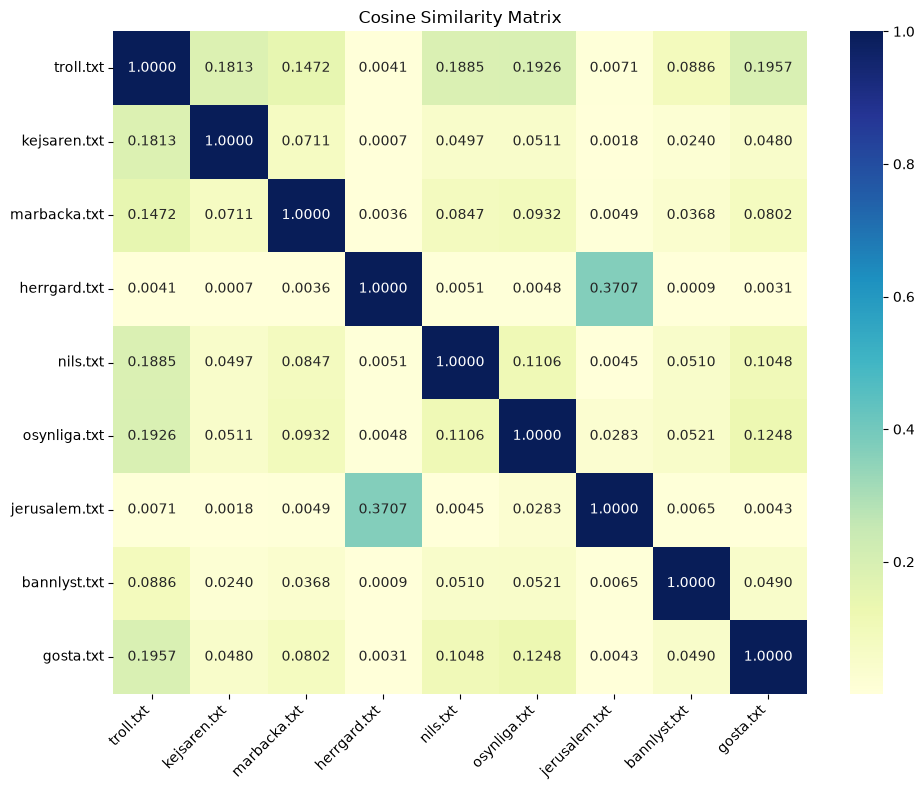

In [18]:
tfidf_scores = tf_idf(master_idx, corpus_files)

sim_matrix = pd.DataFrame([
    [cosine_similarity(tfidf_scores[doc1], tfidf_scores[doc2]) for doc2 in corpus_files]
    for doc1 in corpus_files
], index=corpus_files, columns=corpus_files)

plt.figure(figsize=(10, 8))
seaborn.heatmap(
    sim_matrix, 
    annot=True,       
    fmt=".4f",
    cmap="YlGnBu",
    cbar=True
)

plt.title("Cosine Similarity Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()